In [12]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [13]:
%%R

library(tidyverse)
library('GENOVA')
library(GenomicRanges)
library(GenomicFeatures)
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")

### Load cooler files (10 kb resolution)

In [3]:
%%R

hicpro_adl <- load_contacts('/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_WT_10k.cool', 
                           sample_name = 'Adult', 
                           colour = "black") 

hicpro_old <- load_contacts('/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_old_10k.cool',
                            sample_name = 'Old', 
                            colour = "black")

hicpro_ko <- load_contacts('/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_KO_10k.cool',
                            sample_name = 'S6-KO', 
                            colour = "black")

Reading data...
Reading data...
Reading data...


### Upload loops coordinates, derive union of loops for Adult, Old, S6-KO

In [4]:
%%R

loop_adl <- read.table('/tank/projects/kashuk_sirt6_hic/loops_10k/WT_10k_0.45_loops.bed')
loop_old <- read.table('/tank/projects/kashuk_sirt6_hic/loops_10k/old_10k_0.45_loops.bed')
loop_ko <- read.table('/tank/projects/kashuk_sirt6_hic/loops_10k/KO_10k_0.45_loops.bed')

loops <- rbind(loop_adl, loop_old, loop_ko)
loops <- loops %>% distinct()

In [17]:
%%R

nrow(loop_ko)

[1] 4489


### Visualize average loops ratio

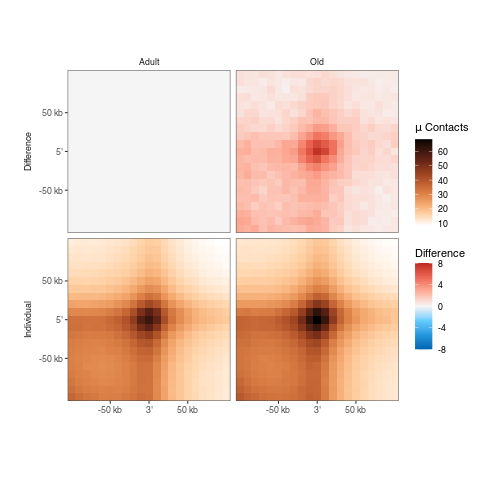

In [5]:
%%R

# Old - Adult
apa <- APA(explist = list(hicpro_adl, hicpro_old), bedpe = loops)

visualise(apa, metric = 'diff', colour_lim_contrast = c(-8, 8))

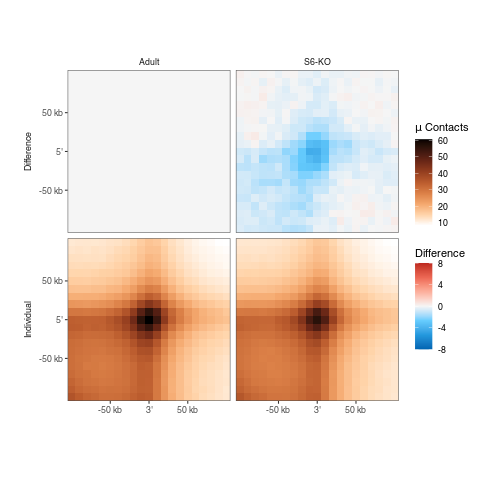

In [6]:
%%R

# S6-KO - Adult
apa <- APA(explist = list(hicpro_adl, hicpro_ko), bedpe = loops)

visualise(apa, metric = 'diff', colour_lim_contrast = c(-8, 8))

### Loop strength

In [7]:
%%R

loop_strength <- function(hicpro1, hicpro2, loops) {
  # Calculate APA
  apa1 <- APA(hicpro1, bedpe = loops)
  apa2 <- APA(hicpro2, bedpe = loops)
  
  # Extract signals
  signal1 <- as.data.frame(apa1$signal)
  signal2 <- as.data.frame(apa2$signal)
  
  # Calculate difference
  signal_difference <- signal1 - signal2
  signal_matrix <- as.matrix(signal_difference)
  signal_matrix <- matrix(as.numeric(signal_matrix), nrow = nrow(signal_matrix))

  n <- 7  

  # Upper left 7x7 rectangle
  upper_left <- signal_matrix[1:n, 1:n]
  mean_upper_left <- mean(upper_left)

  # Central 7x7 rectangle 
  central <- signal_matrix[8:14, 8:14]
  mean_central <- mean(central)

  # Bottom right 7x7 rectangle 
  d <- nrow(signal_matrix)
  bottom_right <- signal_matrix[(d-n+1):d, (d-n+1):d]
  mean_bottom_right <- mean(bottom_right)

  strength <- round(mean_central - max(abs(mean_upper_left), abs(mean_bottom_right)),2)
  
  return(strength)
}

In [8]:
%%R
loop_strength(hicpro_old, hicpro_adl, loops)

[1] 3.07


In [9]:
%%R
loop_strength(hicpro_ko, hicpro_adl, loops)

[1] -2.12


### Identify up- and down-folded loops

In [11]:
%%R

# Function to perform APA comparison between two datasets
run_apa_comparison <- function(hicpro1, hicpro2, loops) {
  # Calculate APA
  apa1 <- APA(hicpro1, bedpe = loops)
  apa2 <- APA(hicpro2, bedpe = loops)
  
  # Extract raw signals
  signal1 <- as.data.frame(apa1$signal_raw)
  signal2 <- as.data.frame(apa2$signal_raw)
  
  # Calculate difference
  signal_difference <- signal1 - signal2
  
  # Calculate mean differences
  mean_values <- rowMeans(signal_difference, na.rm = TRUE)
  
  signal_difference_mean <- data.frame(
    coor = row.names(signal_difference),
    mean_diff = mean_values
  )
  
  # Split coordinates
  difference_mean <- separate(signal_difference_mean, coor, 
                            into = c("chr1", "start1", "end1", "chr2", "start2", "end2"), 
                            sep = "[;:-]")
  
  # Get top and bottom 10%
  top_10_percentile <- quantile(signal_difference_mean$mean_diff, 0.9, na.rm = TRUE)
  bot_10_percentile <- quantile(signal_difference_mean$mean_diff, 0.1, na.rm = TRUE)
  
  signal_difference_mean_top10 <- signal_difference_mean[signal_difference_mean$mean_diff >= top_10_percentile, ]
  signal_difference_mean_bot10 <- signal_difference_mean[signal_difference_mean$mean_diff <= bot_10_percentile, ]
  
  # Remove NAs
  signal_difference_mean_top10 <- na.omit(signal_difference_mean_top10)
  signal_difference_mean_bot10 <- na.omit(signal_difference_mean_bot10)
  
  # Split coordinates for top and bottom
  difference_mean_top10 <- separate(signal_difference_mean_top10, coor, 
                                   into = c("chr1", "start1", "end1", "chr2", "start2", "end2"), 
                                   sep = "[;:-]")
  difference_mean_bot10 <- separate(signal_difference_mean_bot10, coor, 
                                   into = c("chr1", "start1", "end1", "chr2", "start2", "end2"), 
                                   sep = "[;:-]")
  
  # Return results as a list
  return(list(
    difference_mean = difference_mean,
    difference_mean_top10 = difference_mean_top10,
    difference_mean_bot10 = difference_mean_bot10,
    signal_difference = signal_difference
  ))
}

# Run for apa_old vs apa_adl
results_old_vs_adl <- run_apa_comparison(hicpro_old, hicpro_adl, loops)

# Run for apa_ko vs apa_adl 
results_ko_vs_adl <- run_apa_comparison(hicpro_ko, hicpro_adl, loops)

# Old vs Adult:
old_adl_top10 <- results_old_vs_adl$difference_mean_top10
old_adl_bot10 <- results_old_vs_adl$difference_mean_bot10

# S6-KO vs Adult:
ko_adl_top10 <- results_ko_vs_adl$difference_mean_top10
ko_adl_bot10 <- results_ko_vs_adl$difference_mean_bot10